## An Analysis into The Educational Background of Nobel Memorial Prize Laureates in Economics
*Trang Truong*

The Nobel Prize is namely one of the most, if not the most, prestigious awards in the world in its field. Nobel laureates are recognized for their outstanding contributions in academia, of which greatly benefit humankind

There have been research into the academic background of Nobel laureates, two examples of which are [[LWL21](#id1)]
and [[CT15](#id2)]. However, in their research, Nobel laureates in Economics were excluded.

As an Economics student, I am interested in seeing the educational demographic of Nobel Laureates in Economics to discover the following topics: **(1)** whether leading researchers in Economics have a multidisciplinary educational background, **(2)** whether there is a pattern in the institutions they get their education, and **(3)** whether there exists a difference between their ages at the time of award compared to an average Nobel Laureate from other disciplines.

### Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None
%matplotlib inline

My main data set is from [nobelprize.org API](https://www.nobelprize.org/about/developer-zone-2/).

The laureates dataset contains demographical information about Nobel Prize winner, including basic information about their birthdate, the awarded year, their affiliated institution, and so on.

In [2]:
nobel_lau = pd.read_csv("http://api.nobelprize.org/v1/laureate.csv")

nobel_lau.head()

,id,firstname,surname,born,died,bornCountry,bornCountryCode,bornCity,diedCountry,diedCountryCode,diedCity,gender,year,category,overallMotivation,share,motivation,name,city,country
0,1,Wilhelm Conrad,Röntgen,1845-03-27,1923-02-10,Prussia (now Germany),DE,Lennep (now Remscheid),Germany,DE,Munich,male,1901,physics,NaN,1,"""in recognition of the extraordinary services ...",Munich University,Munich,Germany
1,2,Hendrik A.,Lorentz,1853-07-18,1928-02-04,the Netherlands,NL,Arnhem,the Netherlands,NL,NaN,male,1902,physics,NaN,2,"""in recognition of the extraordinary service t...",Leiden University,Leiden,the Netherlands
2,3,Pieter,Zeeman,1865-05-25,1943-10-09,the Netherlands,NL,Zonnemaire,the Netherlands,NL,Amsterdam,male,1902,physics,NaN,2,"""in recognition of the extraordinary service t...",Amsterdam University,Amsterdam,the Netherlands
3,4,Henri,Becquerel,1852-12-15,1908-08-25,France,FR,Paris,France,FR,NaN,male,1903,physics,NaN,2,"""in recognition of the extraordinary services ...",École Polytechnique,Paris,France
4,5,Pierre,Curie,1859-05-15,1906-04-19,France,FR,Paris,France,FR,Paris,male,1903,physics,NaN,4,"""in recognition of the extraordinary services ...",École municipale de physique et de chimie indu...,Paris,France


For my project, I will also build my own dataset to compensate for the necessary missing information about the Nobel Prize winners in Economics: undergraduate major, graduate major, number of degrees, and educational institutions. So far, there have been 89 Nobel recipients in Economics, which I believe is a manageable number of data to collect for the scope of this project.

### Method

##### 1. Do Nobel Memorial Prize laureates in Economics come from a multidisciplinary background?

- Analyze whether all laureates have a bachelor, master, and doctoral degree
- Analyze the undergraduate majors of the laureates
- Analyze the graduate majors of the laureates


##### 2. Are there any differences between an average Nobel Memorial Prize laureate in Economics' age when the prize is awarded compared to that of an average laureate from other disciplines? 

- Compare the age of laureates in Economics with other laureates (excluding Nobel Peace Prize laureates *since some of the laureates in this category are organizations and the category is also less related to academia than other categories*)

##### 3. Are there any similarities between institutions where Nobel Memorial Prize laureates in Economics get their degrees?

- Analyze the location of laureates' universities
- Analyze whether laureates' universities are private or public

### Creating the dataset

In [3]:
nobel_lau['name'] = nobel_lau['firstname'] + ' ' + nobel_lau['surname']
work_lau = nobel_lau[(nobel_lau['category'] == 'economics')]
work_lau.to_csv ('econ_lau.csv', index = False, header=True)

I did manual data entry to collect information regarding the laureates' undergraduate and graduate education, my entries include:
- undergraduate: Name of the institute where the laureates earn their bachelor degree
- undergraduate type: Type of the undergraduate institute (group: public, private)
- undergrad location: Name of the country in which the institute is located
- undergraduate major 1: Primary undergraduate major
- undergraduate major 2: Secondary undergraduate major
- master: 0 for no Master degree, 1 for having more than 1 Master degrees
- master major: The major of the most recent Master degree
- phd: 0 for no PhD degree, 1 for more than 1 PhD degrees
- graduate: Name of the institute where the laureates earn their doctorate degree
- graduate type: Type of the graduate institute (group: public, private)
- graduate location: Name of the country in which the institute is located
- phd thesis topic 1: The primary discipline to which the thesis address
- phd thesis topic 2: The secondary discipline to which the thesis address (0 for no secondary discipline)
- note: Information about some data assumptions to maintain the dataset's transparency

Notes:
- *While creating the data set, I ran across some difficulties in determining the laureates' undergraduate major and also their PhD thesis topics. Therefore, some assumptions were made according to additional comments about their mentors and interests.*
- *I focused mainly on the institute where the laureates earn their doctorate and undergraduate degree, since I believe the undergraduate and graduate degrees have more important influences on their academia career. Furthermore, not all laureates have a master degree. Therefore, I omitted the information about the graduate institutes to preserve the data's focus.*

Sources:
- [Wikipedia](https://en.wikipedia.org/wiki/Main_Page)
- [nobelprize.org](https://www.nobelprize.org/)
- [Britannica](https://www.britannica.com/)
- [Econlib.org](https://www.econlib.org/)

#### Here is the completed data set

In [4]:
econ_lau = pd.read_csv('econ_lau_done.csv')

econ_lau = econ_lau.drop(['firstname','surname','id','overallMotivation'],axis = 1)
econ_lau = econ_lau [['name','category','year','gender','motivation', 'undergraduate', 'undergraduate type','undergrad location','undergraduate major 1', 'undergraduate major 2',
                      'master', 'master major', 'phd', 'graduate', 'graduate type','graduate location', 'phd thesis topic 1', 'phd thesis topic 2',
                      'share', 'born', 'died', 'bornCountry', 'bornCountryCode', 'bornCity','diedCountry', 'diedCountryCode', 'diedCity',
                      'share','city','country']]
econ_lau.head()

,name,category,year,gender,motivation,undergraduate,undergraduate type,undergrad location,undergraduate major 1,undergraduate major 2,...,died,bornCountry,bornCountryCode,bornCity,diedCountry,diedCountryCode,diedCity,share,city,country
0,Ragnar Frisch,economics,1969,male,"""for having developed and applied dynamic mode...",University of Oslo,public,Norway,economics,0,...,1973-01-31,Norway,NO,Oslo,Norway,NO,Oslo,2,Oslo,Norway
1,Jan Tinbergen,economics,1969,male,"""for having developed and applied dynamic mode...",Leiden University,public,the Netherlands,mathematics,physics,...,1994-06-09,the Netherlands,NL,the Hague,the Netherlands,NL,the Hague,2,Rotterdam,the Netherlands
2,Paul A. Samuelson,economics,1970,male,"""for the scientific work through which he has ...",University of Chicago,private,USA,economics,0,...,2009-12-13,USA,US,Gary IN,USA,US,Belmont MA,1,Cambridge MA,USA
3,Simon Kuznets,economics,1971,male,"""for his empirically founded interpretation of...",Columbia University,private,USA,economics,0,...,1985-07-08,Russian Empire (now Belarus),BY,Pinsk,USA,US,Cambridge MA,1,Cambridge MA,USA
4,John R. Hicks,economics,1972,male,"""for their pioneering contributions to general...",Clifton College,public,United Kingdom,unclear,0,...,1989-05-20,United Kingdom,GB,Warwick,United Kingdom,GB,Blockley,2,Oxford,United Kingdom


### 1. Do Nobel Memorial Prize laureates in Economics come from a multidisciplinary background?

##### Analyze whether all laureates have a bachelor, master, and doctoral degree

Before I go into further details, I want to quickly illustrate the types of degrees that the laureates have. 

In [5]:
count_under = econ_lau['undergraduate major 1'].count() - 1
count_mas = econ_lau[econ_lau['master']==1]['master'].count()
count_doc = econ_lau[econ_lau['phd']==1]['phd'].count()
econ_deg = pd.DataFrame({'undergrad':count_under,'master':count_mas,'doctorate':count_doc},index = ['count'])

econ_deg

,undergrad,master,doctorate
count,88,34,88


As shown in the data, while all laureates have a undergraduate and doctorate degree, only a small of number of them have a master degree. Therefore, in this project, I will focus mainly on the laureates' doctorate education.

##### Analyze the undergraduate majors of the laureates

I will present the undergraduate majors of the laureates under pie charts. The data is separated into bins of 10 years (a decade) to see whether there is a systematic change overtime.

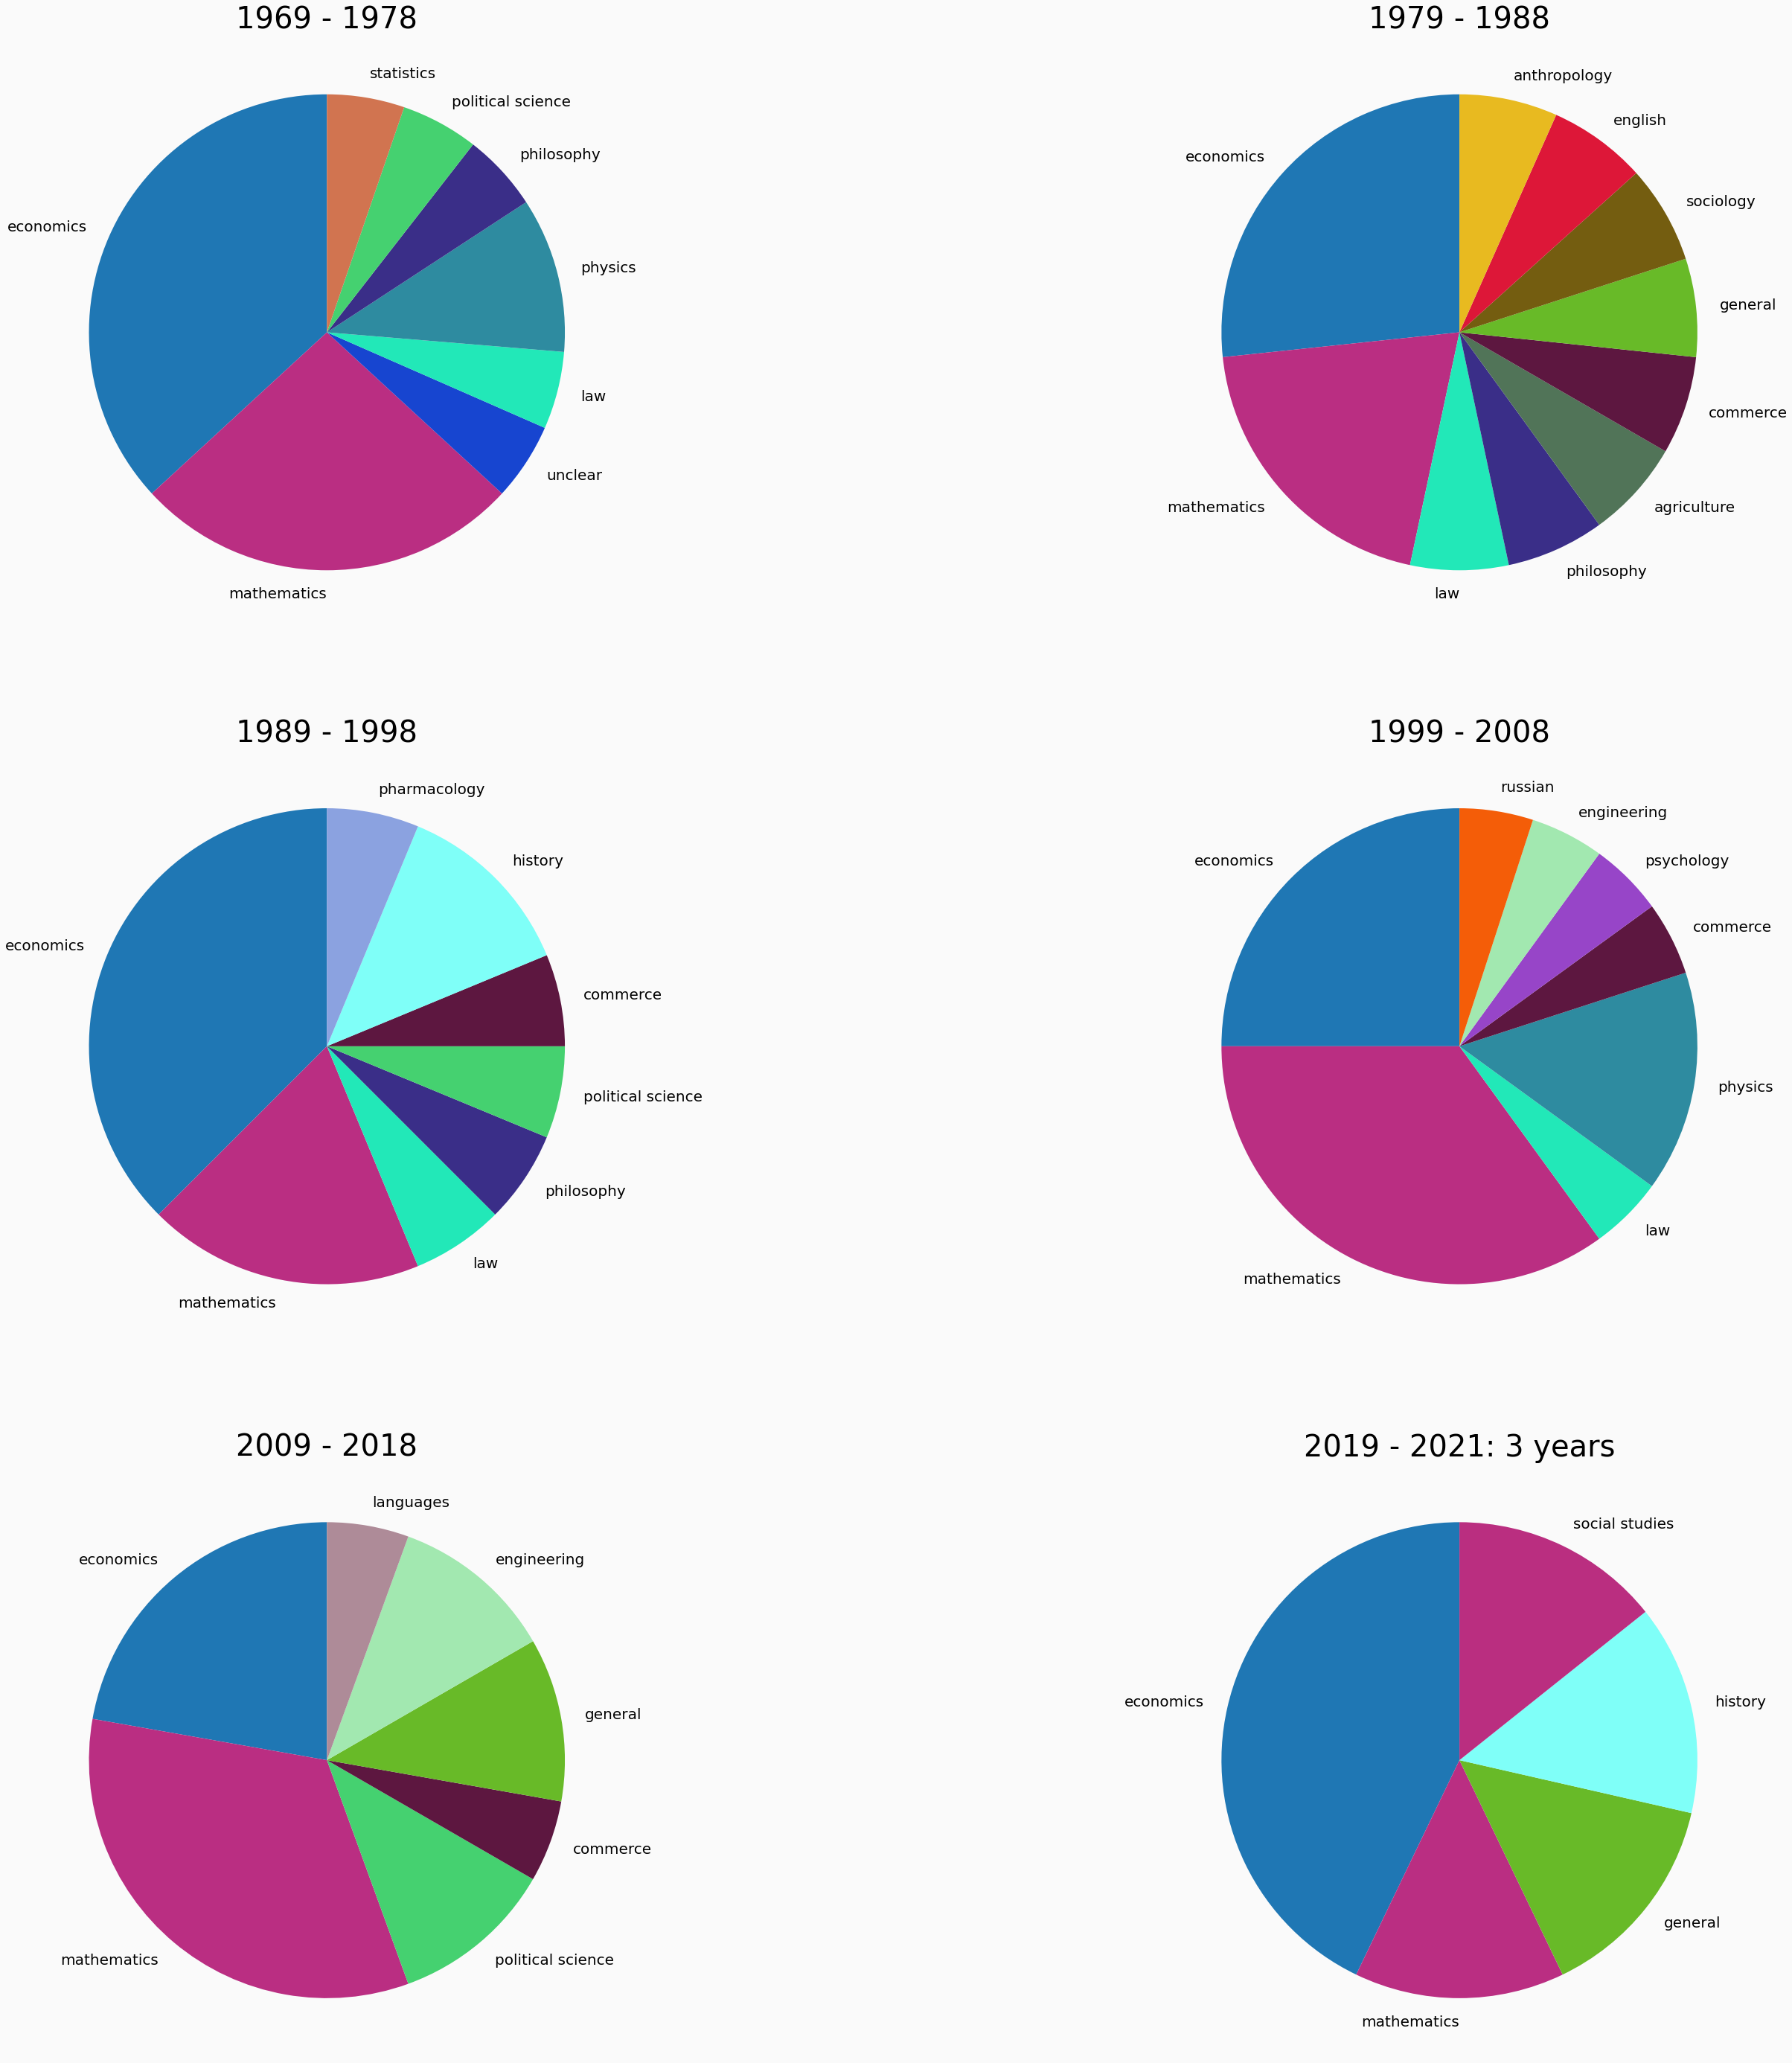

In [6]:
econ_under = econ_lau[['year','undergraduate major 1', 'undergraduate major 2']]

decade =[]

for i in econ_under['year']:
    decade.append((i-1969)//10 +1)

econ_under['decade'] = decade

#get a list of unique majors
major_1 = list(econ_under['undergraduate major 1'].unique())
major_2 = list(econ_under['undergraduate major 2'].unique())
major_3 = list(econ_lau['phd thesis topic 1'].unique())
major_4 = list(econ_lau['phd thesis topic 1'].unique())
major_under = major_1
major_under.extend(x for x in major_2 if x not in major_1)
major_grad = major_3
major_grad.extend(x for x in major_4 if x not in major_3)
major = major_under
major.extend(x for x in major_grad if x not in major_under)

#count number of undergraduate majors 
pivot_1 = econ_under.pivot_table(index = 'decade', columns='undergraduate major 1', values = 'year', aggfunc = pd.Series.nunique)
pivot_1 = pivot_1.reindex(major, axis=1)
pivot_2 = econ_under.pivot_table(index = 'decade', columns='undergraduate major 2', values = 'year', aggfunc = pd.Series.nunique)
pivot_2 = pivot_2.reindex(major,axis=1)

under_toplot = pivot_1.add(pivot_2,fill_value=0).fillna(0)
under_toplot = under_toplot.reset_index()

# this code was adapted from https://stackoverflow.com/questions/41464265/automatically-assign-colors-to-scatter-plot-with-matplotlib
colors = {}
step_size = (256**3) // len(major)
for i, maj in enumerate(major):
    colors[maj] = '#{}'.format(hex(step_size * i)[2:])
colors['economics'] = 'tab:blue'
colors['mathematics'] = '#ba2e82'
del colors['0']

#plot
fig,ax = plt.subplots(3,2,figsize = (50,50))

axe = ax.ravel()

def pie_plot(df, num):
    new = df[df['decade'] == num].set_index('decade')
    new = new.drop(['0'],axis=1)
    new = new.apply(lambda x: x/sum(x)*100, axis=1)
    new = new.T
    new = new.set_axis(['count'], axis=1)
    new.plot.pie(y='count',ax=axe[num-1],legend=None, fontsize = 20, colors = colors.values(),startangle=90)
    return ax

for num in range(1,7):
  pie_plot(under_toplot, num)

axe[0].set_title('1969 - 1978', fontsize = 40)
axe[1].set_title('1979 - 1988', fontsize = 40)
axe[2].set_title('1989 - 1998', fontsize = 40)
axe[3].set_title('1999 - 2008', fontsize = 40)
axe[4].set_title('2009 - 2018', fontsize = 40)
axe[5].set_title('2019 - 2021: 3 years', fontsize = 40)

bgcolor = (250/255, 250/255, 250/255)
fig.set_facecolor(bgcolor)

for i in range(0,6):
  axe[i].set_ylabel('')


From the pie chart, we can see that the majority of Nobel prize winners in Economics have an undergraduate degree in Economics. A significant number of them have a background in Mathematics. For example, from 1999 to 2018, the majority of Nobel prize winners have an undergraduate background in Mathematics. 

*In the last pie chart, the data only consists of 3 years, compared to other pie charts that take data of 10 years. Therefore, although it seems like more Nobel prize winners have a more focused education in Economics recently, the data is highly skewed and such conclusion is biased.*

Now we look at the aggregate data regarding the undergraduate majors of all Nobel prize winners from 1969 to 2021:

Text(0.5, 0.98, 'Undergraduate majors of all Nobel Prize winners')

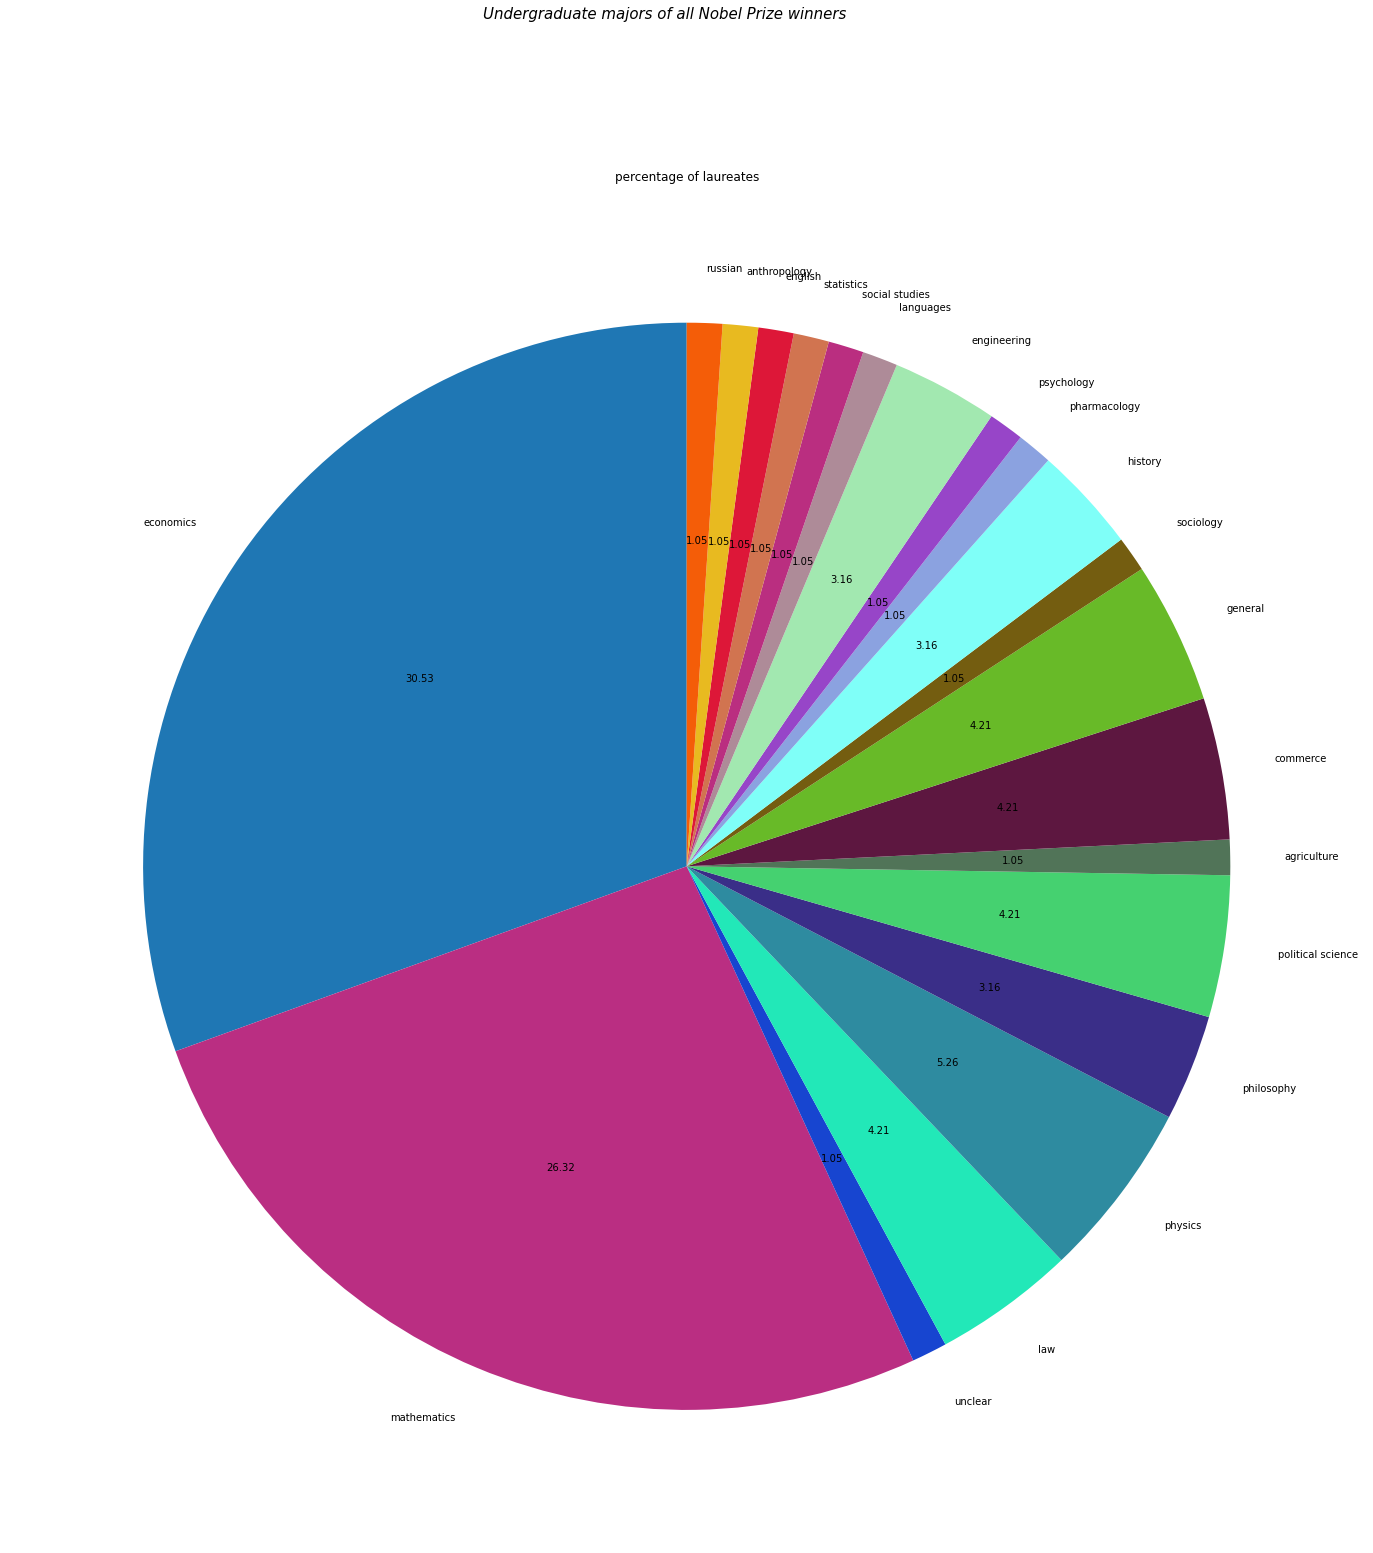

In [7]:
under_total = under_toplot.drop(['decade','0'], axis = 1).sum()
under_total = under_total[under_total != 0]
under_total.plot.pie(figsize = (25,25),ylabel = '', title = 'percentage of laureates', fontsize = 10,  colors = colors.values(), autopct='%.2f', startangle=90)
plt.suptitle('Undergraduate majors of all Nobel Prize winners', style = 'oblique', fontsize = '15')

This graph confirms that most Nobel prize winners either have an undergraduate degree in Mathematics or Economics. A variety of other disciplines was studied by the laureates, although the individual number is not significant.

As expected, the majority of Nobel laureates in Economics have a background in Economics and Mathematics.

##### Analyze the graduate (doctorate) majors of the laureates

Using the same method, I want to see whether the laureates' graduate disciplines differ greatly from the general picture of their undergraduate degrees. For this section, I want to focus specifically in the laureates's doctorate education since not all laureates own a master degree. 

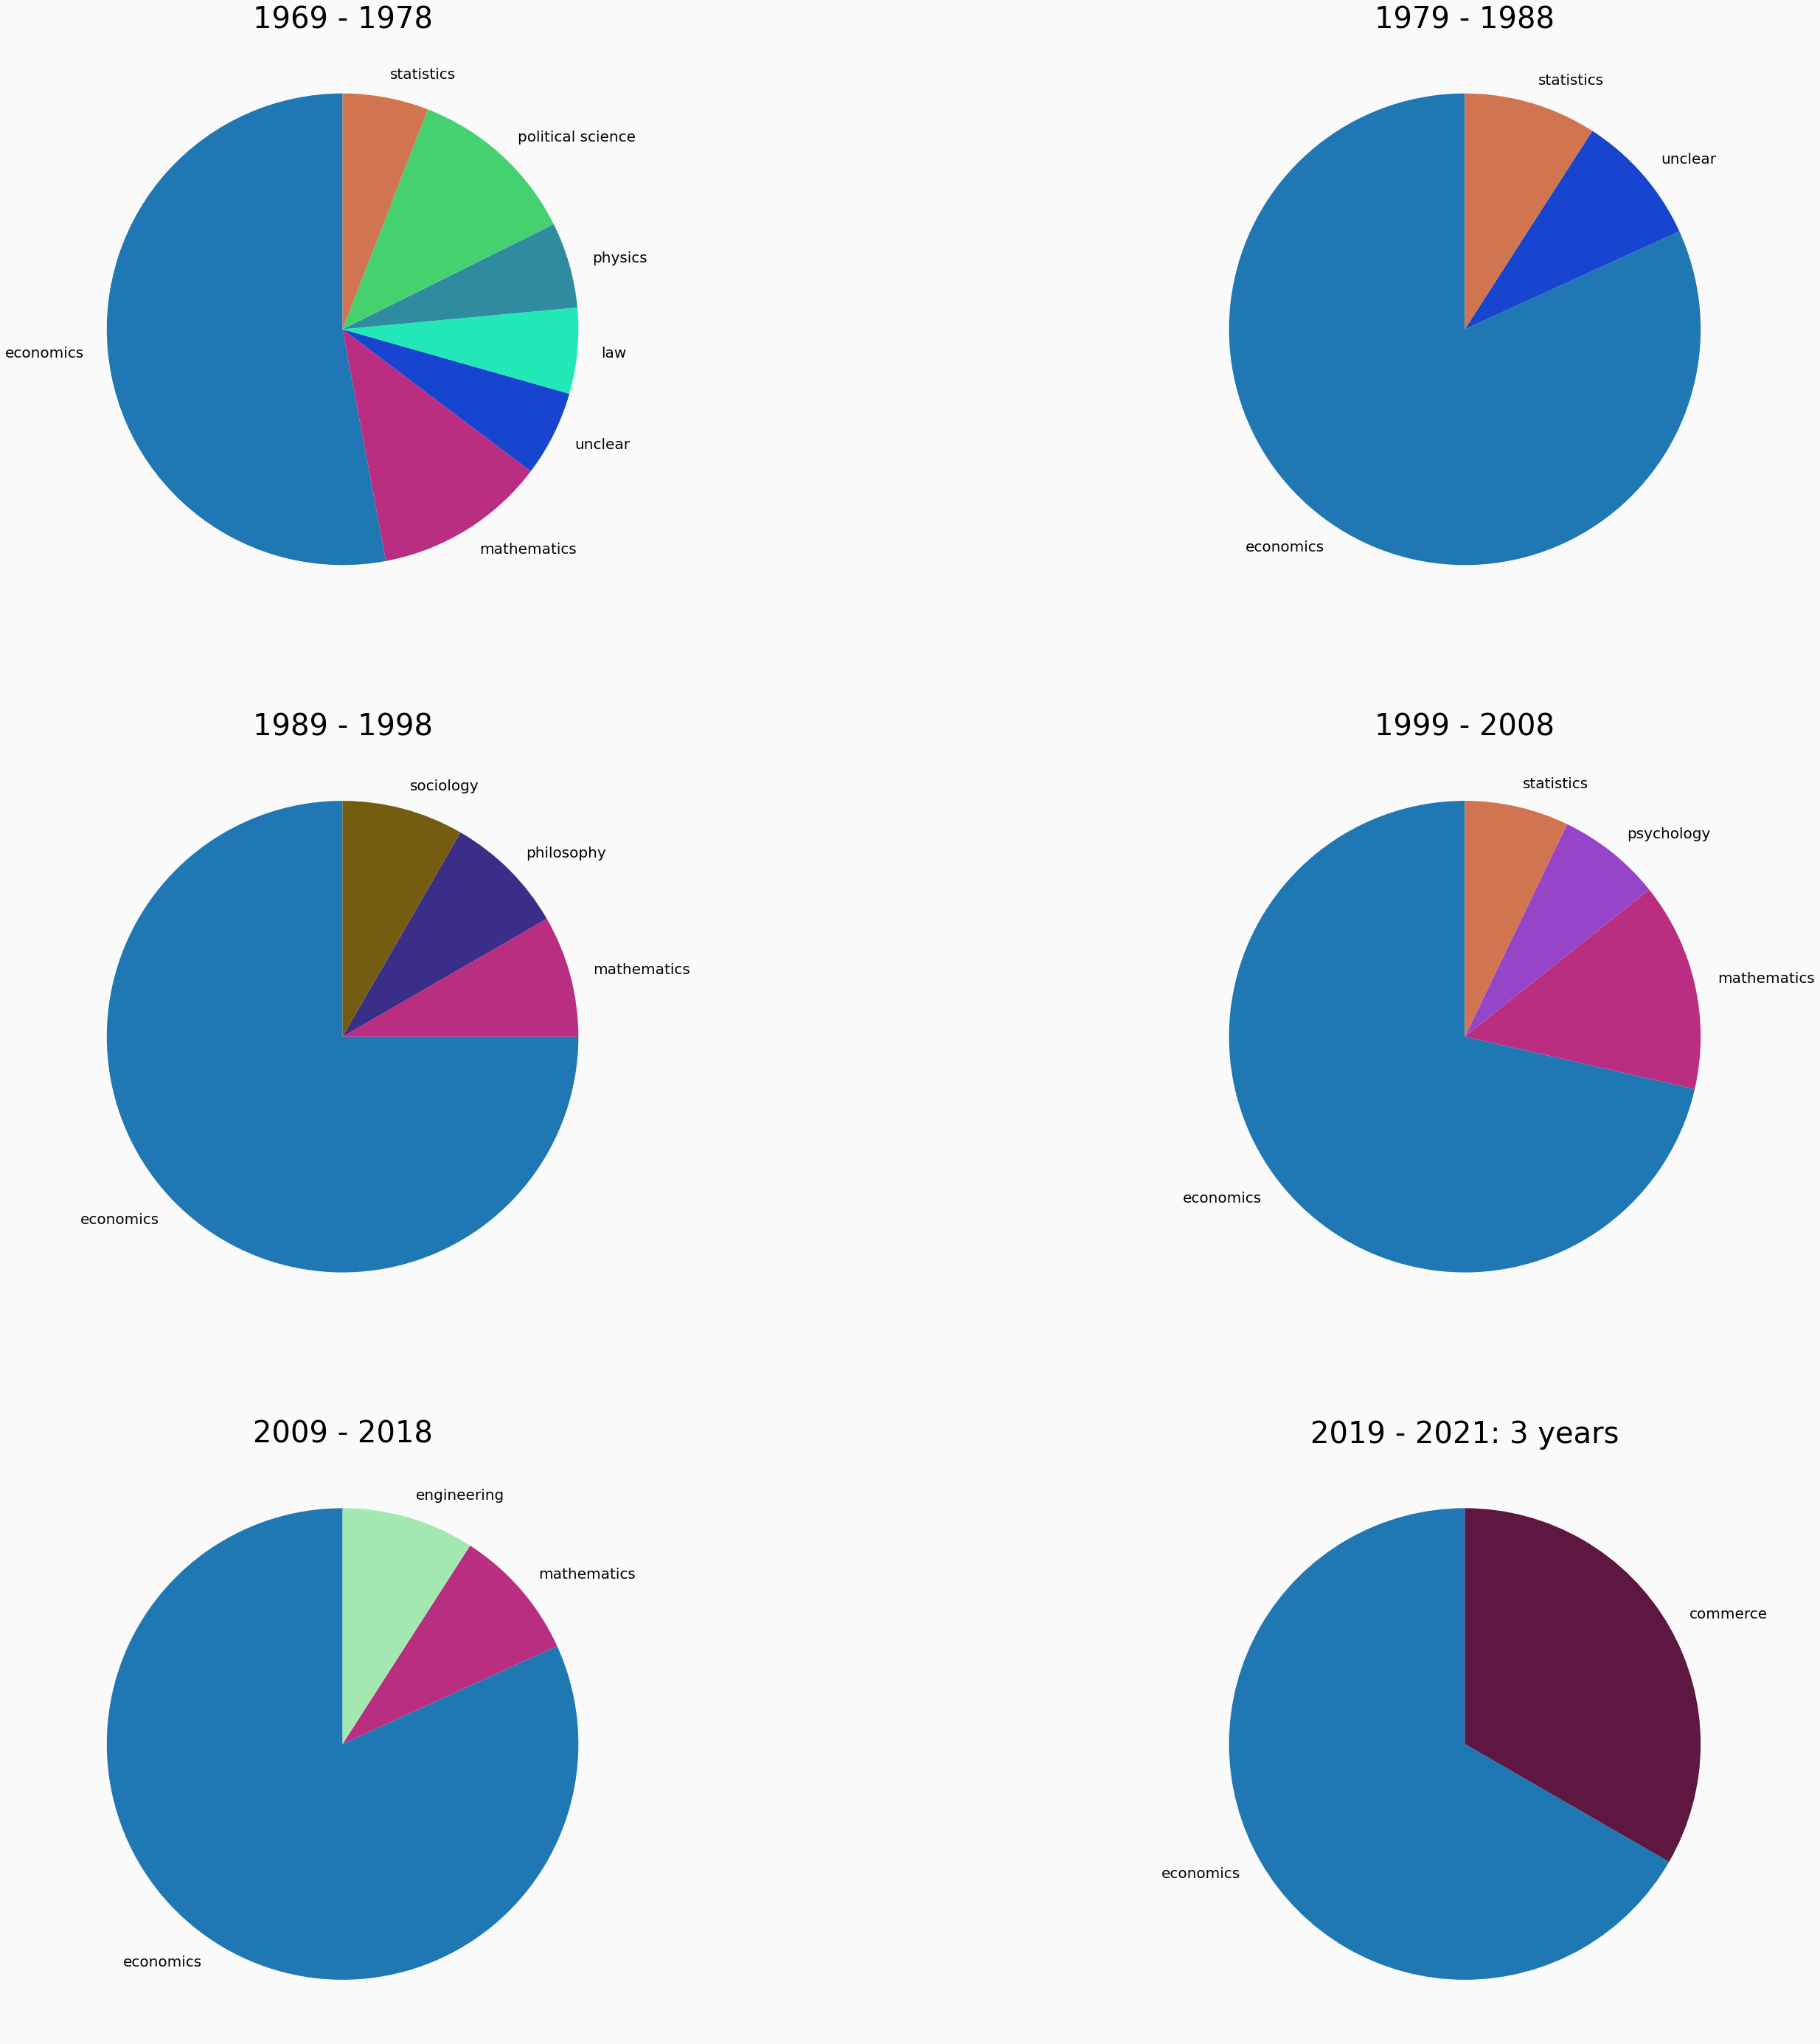

In [8]:
econ_doc = econ_lau[['year', 'phd thesis topic 1','phd thesis topic 2']]

econ_doc['decade'] = decade

# count number of doctorate majors
pivot_3 = econ_doc.pivot_table(index = 'decade', columns='phd thesis topic 1', values = 'year', aggfunc = pd.Series.nunique)
pivot_3 = pivot_3.reindex(major, axis=1)
pivot_4 = econ_doc.pivot_table(index = 'decade', columns='phd thesis topic 2', values = 'year', aggfunc = pd.Series.nunique)
pivot_4 = pivot_4.reindex(major,axis=1)

doc_toplot = pivot_3.add(pivot_4,fill_value=0).fillna(0)
doc_toplot = doc_toplot.reset_index()

# plot
fig,ax = plt.subplots(3,2,figsize = (50,50))

axe = ax.ravel()

for num in range(1,7):
  pie_plot(doc_toplot, num)

axe[0].set_title('1969 - 1978', fontsize = 40)
axe[1].set_title('1979 - 1988', fontsize = 40)
axe[2].set_title('1989 - 1998', fontsize = 40)
axe[3].set_title('1999 - 2008', fontsize = 40)
axe[4].set_title('2009 - 2018', fontsize = 40)
axe[5].set_title('2019 - 2021: 3 years', fontsize = 40)

bgcolor = (250/255, 250/255, 250/255)
fig.set_facecolor(bgcolor)

for i in range(0,6):
  axe[i].set_ylabel('')


It is apparent that Nobel laureates's doctorate education is highly focused in economics. As Nobel laureates in Economics are well-known researcher in the discipline, this result is expected. 

Although the distribution of aggregate doctorate disciplines across years is an easy guess, I will show the pie chart in the interest of transparency.

Text(0.5, 0.98, 'Doctorate majors of all Nobel Prize winners')

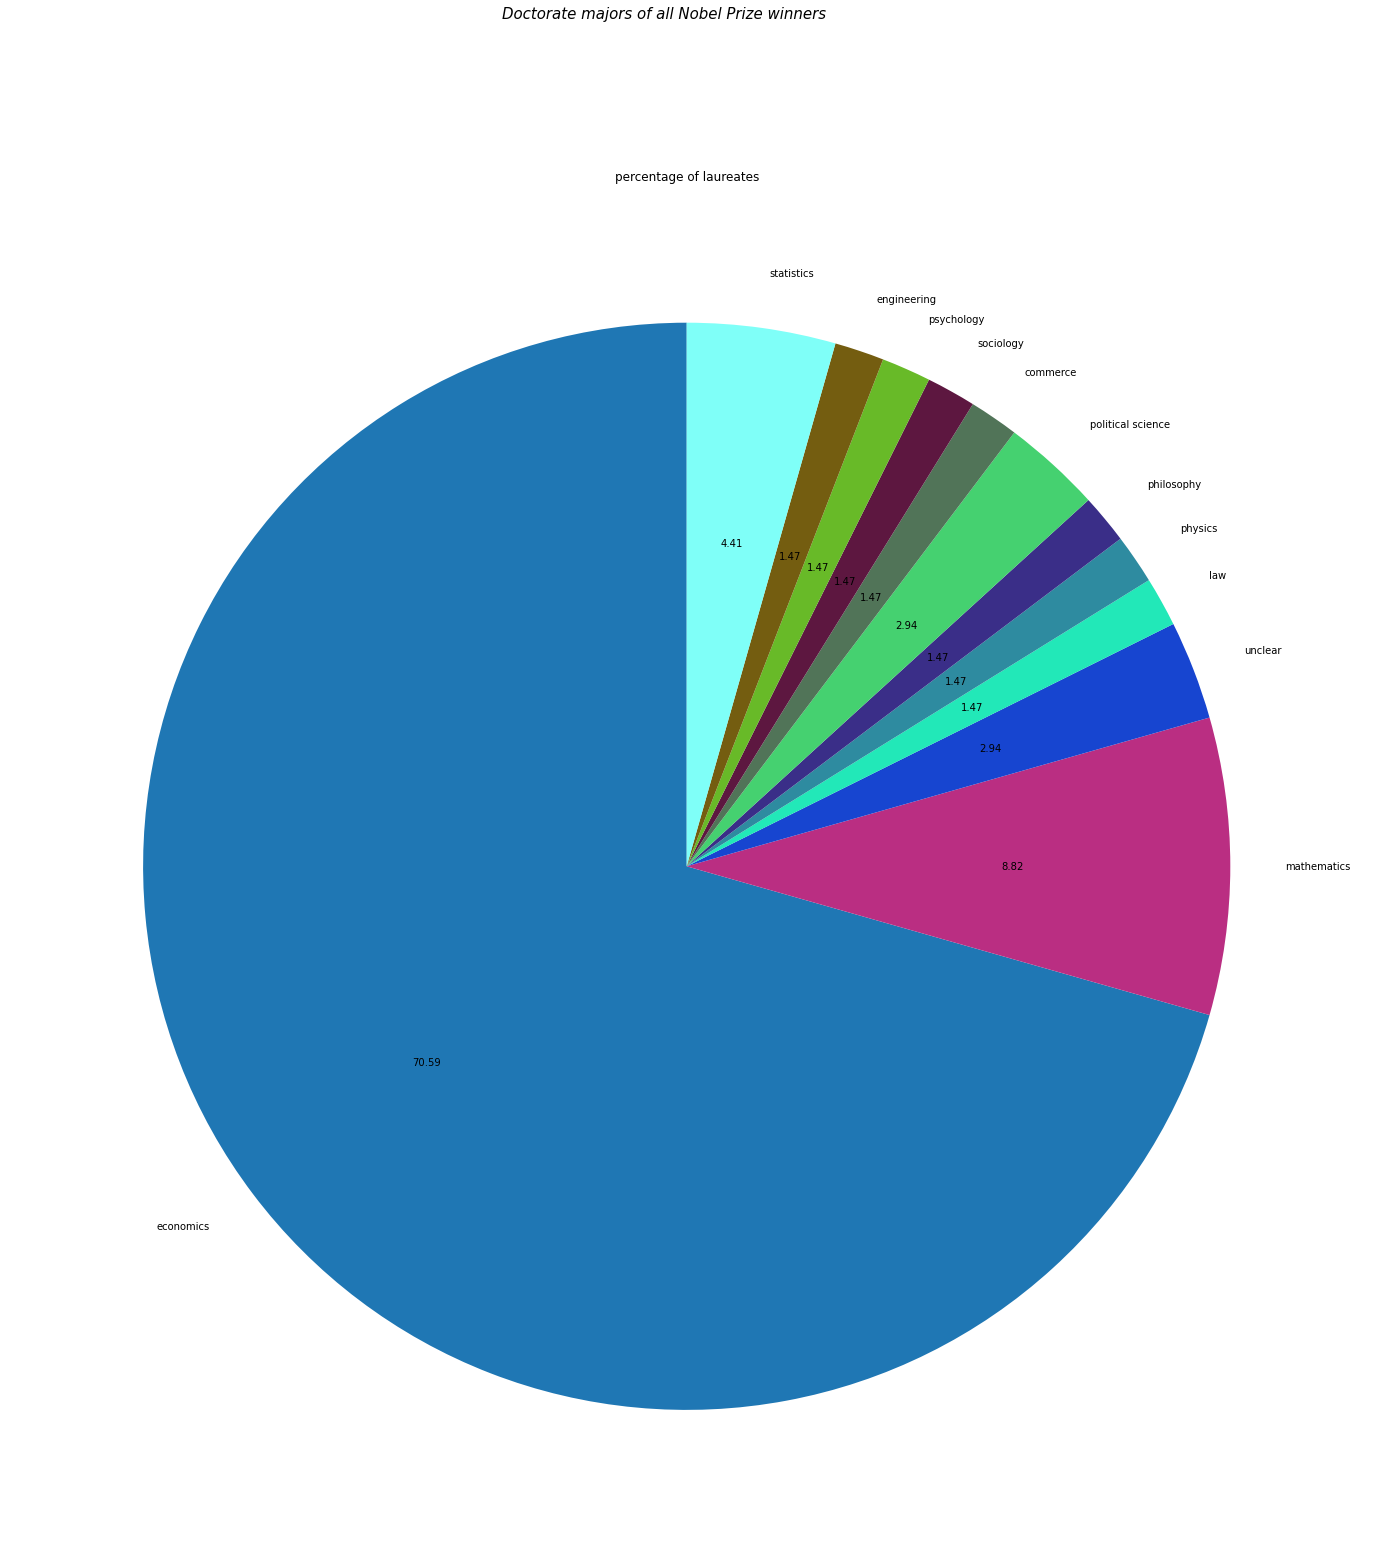

In [9]:
doc_total = doc_toplot.drop(['decade','0'], axis = 1).sum()
doc_total = doc_total[doc_total != 0]
doc_total.plot.pie(figsize = (25,25),ylabel = '', title = 'percentage of laureates', fontsize = 10, colors = colors.values(),autopct='%.2f', startangle = 90)
plt.suptitle('Doctorate majors of all Nobel Prize winners', style = 'oblique', fontsize = '15')

This section provides an interesting comparison with [[LWL21](#id1)]. In [[LWL21](#id1)], the research focuses mainly on the educational backgrounds of laureates of medicine, physics, and chemistry.

In the undergraduate level, laureates of economics seem to come from a wide range of multidisciplinary disciplines like laureates of medicine.

In the graduate level, more laureates of economics, like other disciplines' laureates, get their doctorate degree in their awarded field - economics. The percentage of laureates majoring in economics increases significantly from `30.53 %` in undergraduate to `70.59 %` in graduate; the pattern of which also occurs in medicine, physics, and chemistry. 

### 2. Are there any differences between an average Nobel Memorial Prize laureate in Economics' age when the prize is awarded compared to that of an average laureate from other disciplines? 

##### Compare the age of laureates in Economics with other laureates (excluding Nobel Peace Prize laureates *since some of the laureates in this category are organizations and the category is also less related to academia than other categories*)

Text(0.5, 1.0, 'Average Age of Nobel Prize Laureates at Time of Being Awarded')

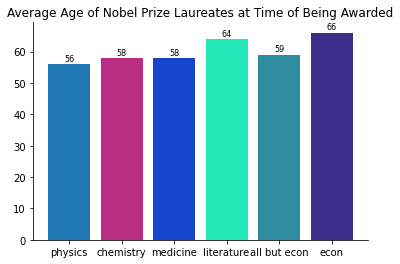

In [10]:
nobel_age = nobel_lau

#only take the year of birth since there are missing data for dates
def trans(val):
    return str(val).replace('-','')[0:4]
    
nobel_age['born'] = nobel_age['born'].apply(trans)

nobel_age.loc[nobel_age.name == 'Michael Houghton', 'born'] = 1949

nobel_age['year'] = nobel_age['year'].astype(float)
nobel_age['born'] = nobel_age['born'].astype(float)

nobel_age['age_awarded'] = nobel_age['year'] - nobel_age['born']
noecon_age = nobel_age.query("category != 'economics' and category != 'peace'")
econ_age = nobel_age.query("category =='economics'")

all_cate = list(noecon_age['category'].unique())

avg_age = {}
for i in all_cate:
    avg_age[i] = int(noecon_age[noecon_age['category'] == i]['age_awarded'].mean())
    
avg_age['all but econ'] = int(noecon_age['age_awarded'].mean())

avg_age['econ'] = int(econ_age['age_awarded'].mean())

ax = plt.subplot()

plt.bar(range(len(avg_age)), list(avg_age.values()), align='center', color = colors.values())
plt.xticks(range(len(avg_age)), list(avg_age.keys()))

ap = avg_age['physics']
ac = avg_age['chemistry']
am = avg_age['medicine']
al = avg_age['literature']
aa = avg_age['all but econ']
ae = avg_age['econ']

plt.annotate(f'{ap}', (0,ap+1), fontsize = 8, ha = 'center')
plt.annotate(f'{ac}', (1,ac+1), fontsize = 8, ha = 'center')
plt.annotate(f'{am}', (2,am+1), fontsize = 8, ha = 'center')
plt.annotate(f'{al}', (3,al+1), fontsize = 8, ha = 'center')
plt.annotate(f'{aa}', (4,aa+1), fontsize = 8, ha = 'center')
plt.annotate(f'{ae}', (5,ae+1), fontsize = 8, ha = 'center')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_title('Average Age of Nobel Prize Laureates at Time of Being Awarded')

The age of economics laureates at the time of being awarded is **higher** than other disciplines. While the percentage of physics laureates with a doctorate degree in physics is `92.3%` [[LWL21](#id1)], the percentage of economics laureates with a doctorate degree is significantly less at around `71%`; this potentially can explain the why economists take more times to be recognized by the Nobel committee. 

However, according to [[LWL21](#id1)], the percentage of medicine laureates with a doctorate degree in medicine is `54%` and the percentage of medicine laureates with a doctorate degree in chemistry is `68.7%`. These statistics of chemistry and medicine are not hugely different from economics. Therefore, the hypothesis that the higher the percentage of specialized doctorate degree, the lower the age of Nobel prize winners lacks strong supporting evidence. I will further address this in the `Conclusion` section.

### 3. Are there any similarities between institutions where Nobel Memorial Prize laureates in Economics get their degrees?

As the previous section has shown that Nobel Laureates have multidisciplinary education background, I want to take an extra step to analyze whether they have a diverse education environment. To show this, I will look into the location in which the institutes, where the laureates attained their bachelor and phd, is located. I will further my analysis by looking into whether most laureates attend public or private university.

##### Analyze the location of laureates' universities

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from bokeh.io import output_notebook
from bokeh.plotting import figure, ColumnDataSource
from bokeh.io import output_notebook, show, output_file
from bokeh.plotting import figure
from bokeh.models import GeoJSONDataSource, LinearColorMapper, ColorBar, HoverTool, Title
from bokeh.palettes import brewer
output_notebook()
import json

Loading BokehJS ...

In [12]:
under_loc = econ_lau[['undergraduate', 'undergrad location','undergraduate type']]

under_loc['public'] = [1 if i =='public' else 0 for i in under_loc['undergraduate type']]

under_loc['private'] = [1 if i =='private' else 0 for i in under_loc['undergraduate type']]

series_pr = under_loc.groupby(pd.Grouper(key = 'undergrad location'))['private'].sum()
series_pu = under_loc.groupby(pd.Grouper(key = 'undergrad location'))['public'].sum()

count_undergrad = pd.DataFrame({'count_laureates':under_loc['undergrad location'].value_counts(),'private':series_pr,'public':series_pu})

# world polygon
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
world = world.set_index("iso_a3")

# clean data for merging
count_undergrad = count_undergrad.reset_index().replace({'the Netherlands':'Netherlands','USA': 'United States of America','USSR (now Russia)': 'Russia'})

# merge and create geopanda
under_loc = pd.merge(count_undergrad, world, how='right',left_on = 'index', right_on = 'name')
under_loc = under_loc.rename(columns = {'undergrad location': 'count_laureates','undergraduate type':'undergraduate_type'})
geo_under = gpd.GeoDataFrame(under_loc, geometry="geometry")


In [13]:
under_loc_json = geo_under.to_json()
under_loc_geojson=GeoJSONDataSource(geojson=under_loc_json)

color_mapper = LinearColorMapper(palette = brewer['RdBu'][6], low = geo_under['count_laureates'].min(), high = geo_under['count_laureates'].max(),nan_color = 'white')
color_bar = ColorBar(color_mapper=color_mapper, label_standoff=8,width = 500, height = 10,
                     border_line_color=None,location = (0,0), orientation = 'horizontal')
hover = HoverTool(tooltips = [ ('Country','@name'),('Number of Laureates', '@count_laureates'),('Number of Laureates Attended Public Schools','@public'),('Number of Laureates Attended Private Schools','@private')])
p = figure(title="Place of Study of Nobel Laureates: Undergraduate Level", tools=[hover], plot_width = 1000, plot_height = 600)
p.patches("xs","ys",source=under_loc_geojson,
          fill_color = {'field' :'count_laureates', 'transform' : color_mapper},line_color = 'black', line_width = 0.5)
p.add_layout(Title(text="The color bar indicates the number of laureates", text_font_style="italic"), 'above')
p.add_layout(color_bar, 'below')
show(p)

As shown in the map, the US has the highest number of Nobel laureates who attended American universities as an undergraduate. Generally, the majority of Nobel laureates got their bachelor degrees from universities in North America and Europe.

I will use the same method to create a map for the graduate level.

In [14]:
grad_loc = econ_lau[['graduate', 'graduate location','graduate type']]

grad_loc['public'] = [1 if i =='public' else 0 for i in grad_loc['graduate type']]

grad_loc['private'] = [1 if i =='private' else 0 for i in grad_loc['graduate type']]

series_pr_g = grad_loc.groupby(pd.Grouper(key = 'graduate location'))['private'].sum()
series_pu_g = grad_loc.groupby(pd.Grouper(key = 'graduate location'))['public'].sum()

count_grad = pd.DataFrame({'count_laureates':grad_loc['graduate location'].value_counts(),'private':series_pr_g,'public':series_pu_g})

# clean data for merging
count_grad = count_grad.reset_index().replace({'the Netherlands':'Netherlands','USA': 'United States of America','USSR (now Russia)': 'Russia'})

# merge and create geopanda
grad_loc = pd.merge(count_grad, world, how='right',left_on = 'index', right_on = 'name')
grad_loc = grad_loc.rename(columns = {'graduate location': 'count_laureates'})
geo_grad = gpd.GeoDataFrame(grad_loc, geometry="geometry")


In a relatively similar pattern, most laureates got their doctorate education from US universities. Also, all Nobel laureates got their doctorate degrees from universities in North America and Europe.

In [15]:
grad_loc_json = geo_grad.to_json()
grad_loc_geojson=GeoJSONDataSource(geojson=grad_loc_json)

color_mapper = LinearColorMapper(palette = brewer['RdBu'][6], low = geo_grad['count_laureates'].min(), high = geo_grad['count_laureates'].max(),nan_color = 'white')
color_bar = ColorBar(color_mapper=color_mapper, label_standoff=8,width = 500, height = 10,
                     border_line_color=None,location = (0,0), orientation = 'horizontal')
hover = HoverTool(tooltips = [ ('Country','@name'),('Number of Laureates', '@count_laureates'),('Number of Laureates Attended Public Schools','@public'),('Number of Laureates Attended Private Schools','@private')])
p = figure(title="Place of Study of Nobel Laureates: Graduate Level", tools=[hover], plot_width = 1000, plot_height = 600)
p.patches("xs","ys",source=grad_loc_geojson,
          fill_color = {'field' :'count_laureates', 'transform' : color_mapper}, line_color ='black', line_width = 0.5)
p.add_layout(Title(text="The color bar indicates the number of laureates", text_font_style="italic"), 'above')
p.add_layout(color_bar, 'below')
show(p)


It remains that most Nobel Laureates got their education from American universities for both their bachelor and PhD degree. Furthermore, Nobel Laureates in Economics come from only universities in North America and Europe.

##### Analyze whether laureates' universities are private or public

The above maps are better for seeing how many laureates attended local university of each country. I will make different maps to highlight the percentage of laureates attended local public university of each country.

In [16]:
geo_under['pct'] = geo_under['public']/(geo_under['private'] + geo_under['public'])*100

under_pp_json = geo_under.to_json()
under_pp_geojson=GeoJSONDataSource(geojson=under_pp_json)

color_mapper = LinearColorMapper(palette = brewer['RdYlGn'][6], low = geo_under['pct'].min(), high = geo_under['pct'].max(),nan_color = 'white')
color_bar = ColorBar(color_mapper=color_mapper, label_standoff=8,width = 500, height = 10,
                     border_line_color=None,location = (0,0), orientation = 'horizontal')
hover = HoverTool(tooltips = [ ('Country','@name'),('Number of Laureates', '@count_laureates'),('Number of Laureates Attended Public Schools','@public'),('Number of Laureates Attended Private Schools','@private'),('Percentage of Public School','@pct')])
p = figure(title="The number of laureates attending university of each country: Undergraduate Level", tools=[hover], plot_width = 1000, plot_height = 600)
p.patches("xs","ys",source=under_pp_geojson,
          fill_color = {'field' :'pct', 'transform' : color_mapper},line_color = 'black', line_width = 0.5)
p.add_layout(Title(text="The color bar indicates the percentage of laureates who attended public schools", text_font_style="italic"), 'above')
p.add_layout(color_bar, 'below')
show(p)

An interesting feature in the map is that, different from other countries, for laureates that went to university in the US, the majority of them attended private universities. However, it should be noted that, even in the US, laureates didn't only attend private universities. 

In [17]:
geo_grad['pct'] = geo_grad['public']/(geo_grad['private'] + geo_grad['public'])*100

grad_pp_json = geo_grad.to_json()
grad_pp_geojson=GeoJSONDataSource(geojson=grad_pp_json)

color_mapper = LinearColorMapper(palette = brewer['RdYlGn'][6], low = geo_grad['pct'].min(), high = geo_grad['pct'].max(),nan_color = 'white')
color_bar = ColorBar(color_mapper=color_mapper, label_standoff=8,width = 500, height = 10,
                     border_line_color=None,location = (0,0), orientation = 'horizontal')
hover = HoverTool(tooltips = [ ('Country','@name'),('Number of Laureates', '@count_laureates'),('Number of Laureates Attended Public Schools','@public'),('Number of Laureates Attended Private Schools','@private'),('Percentage of Public School','@pct')])
p = figure(title="The number of laureates attending university of each country: Graduate Level", tools=[hover], plot_width = 1000, plot_height = 600)
p.patches("xs","ys",source=grad_pp_geojson,
          fill_color = {'field' :'pct', 'transform' : color_mapper}, line_color ='black', line_width = 0.5)
p.add_layout(Title(text="The color bar indicates the percentage of laureates who attended public schools", text_font_style="italic"), 'above')
p.add_layout(color_bar, 'below')
show(p)


A similar pattern of university's types is reflected in the laureates' graduate education. In the US, more laureates attended private university for their doctorate degree. However, the fact that laureates don't only come from private universities remains. 

Although all Nobel laureates attended universities in North America and Europe (a dominated number of them attended universities in the US), conclusions about different races' competency can hardly be made, since the laureates' place of education is not strongly correlated with their place of birth. For example, a more general analysis done by [[BF](#id3)] shows that a number of US-based Nobel prize winners are immigrants.

A potential explanation for the focus of Nobel laureates in North American and European universities is the "selection effect".  According to [[CT15](#id2)], the selection effect refers to the effect that talented students are attracted to large and prestigious institutions. 

Furthermore, world-class institutions attract a great number of renowned researchers and prize winners. As Nobel laureates Samuelson is cited in [[CT15](#id2)]: "I can tell you how to get a Nobel Prize. One condition is to have great teachers." To further Samuelson's point, it is also more likely for a person to win a Nobel prize if they are motivated by a Nobel prize winner, according to [[TE](#id4)].

All the factors (selection effect, mentor, and nominations) create a potential chain effect that leads to the majority of Nobel laureates to attend universities in North America and Europe, or perhaps, the majority of Nobel laureates coming from universities in North America and Europe.

### Conclusion

Main conclusions:
- The majority of Nobel laureates in economics have an undergraduate background in Economics and Mathematics.
- Around `71%` of Nobel laureates in economics have a graduate degree in Economics - the transition into a higher percentage of winning-prize field of the doctorate degree is similar to that of laureates in medicine, physics, and chemistry.
- A small percentage of Nobel laureates in economics come from **a wide range of different disciplines**.


- Nobel laureates in economics have **the highest age** at the time of winning. However with the limited scope of this project, I couldn't find a sufficient answer to this question. Further research can be conducted to look into the research work of Nobel laureates in economics, since the research nature of different disciplines varies. More research can look into whether the majority of Nobel laureates in economics' works are empirical or theoretical oriented.


- The majority of Nobel prize winners in economics attended **universities in North America and Europe**.
- Specifically in the US, more Nobel prize winners attended private universities than any where else.
- The skew in data towards western universities and private universities in the US is potentially the cause of the selection effect and the opportunity to be taught or referred by renowned researchers.

### References
<a id='id1'></a>
\[LWL21\] Li, D., Wang, Y., and Liu, Z. (2021). Academic background of Nobel prize laureates reveals the importance of multidisciplinary education in medicine. *Social Sciences & Humanities Open,* 1(3). https://doi.org/10.1016/j.ssaho.2021.100114.

<a id='id2'></a>
\[CT15\] Chan, H.F. and Torgler, B. (2015). The implications of educational and methodological background for the career success of Nobel laureates: an investigation of major awards. *Scientometrics,* 102(1), 847-863. https://doi.org/10.1007/s11192-014-1367-7

<a id='id3'></a>
\[BF\] Aldhous P. (2017, Jan 31). 'These Nobel Prize Winners Show Why Immigration Is So Important For American Science'. *BuzzFeed*. https://www.buzzfeednews.com/article/peteraldhous/immigration-and-science

<a id='id4'></a>
\[TE\] (2021, Oct 9). 'The best way to win a Nobel is to get nominated by another laureate'. *The Economists*. https://www.economist.com/graphic-detail/2021/10/09/the-best-way-to-win-a-nobel-is-to-get-nominated-by-another-laureate